In [98]:
# declare libraries
import json
import geojson
import os
import pathlib
import time
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely

from zipfile import ZipFile
import rioxarray as rxr
import xarray as xr
import rasterio
from rasterio.plot import show

from shapely.geometry import shape, mapping
from shapely.validation import explain_validity
from shapely.ops import unary_union
from shapely.wkt import loads

from sklearn.cluster import DBSCAN

import pprint as pp

import matplotlib.pyplot as plt

import requests
from requests.auth import HTTPBasicAuth
from planet import Session, DataClient, OrdersClient, Auth, Planet

import os
import sys

from pyproj import Transformer

sys.path.append("../utils")

import config
# import planet_api

import pyproj

# Point this to where your actual proj.db is (inside your conda env)
# pyproj.datadir.set_data_dir("/Users/rachelfswick/.conda/envs/wildfire_prep/share/proj") 

from pyproj import CRS

# declare misc vars
crs = "EPSG:4326"
#crs = "EPSG:3310"
county_filepath = "/capstone/wildfire_prep/data/ca_counties/CA_Counties.shp"
# sb_bbox = [-125, 34.25, -119.0, 38.0]

data_api_url = "https://api.planet.com/data/v1"
orders_api_url = 'https://api.planet.com/compute/ops/orders/v2' 

# load CA county shps
counties = (
   gpd
   .read_file(county_filepath)
   .to_crs(crs)
  )

# isolate sb shp
sb_county = (
    counties
    .loc[counties["NAME"] == "Santa Barbara"]
    .explode(ignore_index=True)
    .iloc[[0]]
    )

# import 2019 buffer geometries
with open('/capstone/wildfire_prep/data/training_geometries/training_geometries_2019.geojson', 'r') as file:
    buffer_2019 = dict(geojson.load(file))["features"]

buffer_2019_df = gpd.read_file("/capstone/wildfire_prep/data/training_geometries/training_geometries_2019.geojson")


planet_api = config.planet_api

In [48]:
# test buffer geojson by printing it
pp.pprint(
    buffer_2019[0]["geometry"]["coordinates"][0]
    )

[[-2892.357167, -371905.216569],
 [-2813.178692, -371905.216569],
 [-2813.178692, -371821.557405],
 [-2892.357167, -371821.557405],
 [-2892.357167, -371905.216569]]


In [6]:
# make subset
buffer_subset = buffer_2019[:5]

pp.pprint(buffer_subset)

[{"geometry": {"coordinates": [[[-2892.357167, -371905.216569], [-2813.178692, -371905.216569], [-2813.178692, -371821.557405], [-2892.357167, -371821.557405], [-2892.357167, -371905.216569]]], "type": "Polygon"}, "properties": {"Date": "2019-06-05T00:00:00", "apn": null, "fulcrum_id": "d9a4d031-d16d-4c84-b32c-f3fcd7d945df", "month": 6, "status": "Compliant", "year": 2019}, "type": "Feature"},
 {"geometry": {"coordinates": [[[-8475.39365, -370860.259107], [-8368.416361, -370860.259107], [-8368.416361, -370753.933861], [-8475.39365, -370753.933861], [-8475.39365, -370860.259107]]], "type": "Polygon"}, "properties": {"Date": "2019-05-09T00:00:00", "apn": null, "fulcrum_id": "7f9b6d98-548d-4b94-97c6-82cbddf84d99", "month": 5, "status": "Compliant", "year": 2019}, "type": "Feature"},
 {"geometry": {"coordinates": [[[-8253.618412, -371183.727047], [-8136.128554, -371183.727047], [-8136.128554, -371073.706652], [-8253.618412, -371073.706652], [-8253.618412, -371183.727047]]], "type": "Polygo

In [7]:
test_gdf = gpd.read_file("/capstone/wildfire_prep/data/training_geometries/training_geometries_2019.geojson")

/tmp/ipykernel_4162729/3909408612.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  convex_hull = gdf_convex.unary_union.convex_hull


<Axes: >

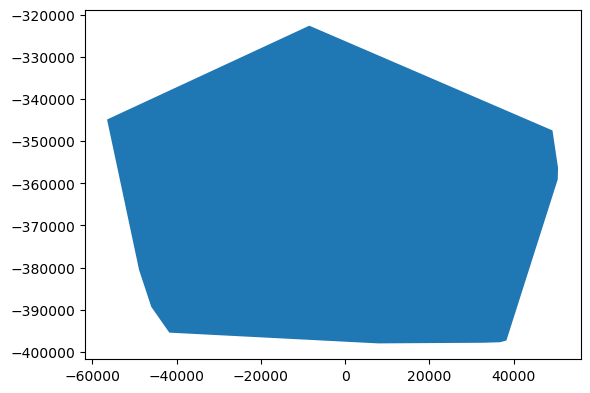

In [349]:
gdf_convex = test_gdf
convex_hull = gdf_convex.unary_union.convex_hull
gdf_hull = gpd.GeoDataFrame(geometry=[convex_hull], crs=test_gdf.crs)

gdf_hull.plot()
# ax = gdf_convex["convex"].plot(alpha=.5)  # saving the first plot as an axis and setting alpha (transparency) to 0.5
# gdf_convex["boundary"].plot(ax=ax, color="white", linewidth=.5)  # passing the first plot and setting linewitdth to 0.5

In [309]:
# merged = test_gdf["geometry"].buffer(0.000001).unary_union

# test_merge = gpd.GeoDataFrame(geometry=[merged], crs = test_gdf.crs)
# test_merge

sandbox_gdf = test_gdf

coords = np.array([geom.centroid.coords[0] for geom in sandbox_gdf.geometry])

clustering = DBSCAN(eps=1500, min_samples=2).fit(coords)
sandbox_gdf["cluster"] = clustering.labels_

# coords_2 = 
# clustering_2 = 

grouped = sandbox_gdf.dissolve(by="cluster")
# gpd.GeoDataFrame(geometry= [grouped.iloc[0].geometry], crs = sandbox_gdf.crs).plot()
# grouped.iloc[0:1].plot()
# sandbox_gdf.plot()

grouped_wgs = grouped.to_crs("epsg:4326")
# grouped_wgs = gpd.GeoDataFrame(geometry=grouped_wgs)
# grouped_wgs = shape(grouped_wgs)
# shape(grouped_wgs)
# for group in grouped_wgs[0:5]:
# grouped_wgs[0:1].plot()

# grouped_wgs.geometry

# shape(sandbox_gdf.groupby("cluster"))

In [310]:
sandbox_gdf[sandbox_gdf["cluster"] == -1]

,fulcrum_id,apn,Date,year,month,status,geometry,cluster
1530,949bd138-edd1-4162-b762-21258357259a,None,2019-06-10,2019,6,Compliant,"POLYGON ((-26286.814 -355576.167, -26192.574 -...",-1
1542,075a14ce-6330-4ec1-8dbe-4b68dc9925bf,None,2019-06-08,2019,6,Compliant,"POLYGON ((-28671.546 -351721.927, -28571.755 -...",-1
4746,c4a87f02-f568-4843-abf9-9244e308ab2b,None,2019-08-01,2019,8,Compliant,"POLYGON ((12182.041 -342068.572, 12272.536 -34...",-1
4750,7e9c36b7-e2b5-49d8-bca7-b977241bb805,None,2019-06-29,2019,6,Compliant,"POLYGON ((3549.394 -329735.572, 3665.818 -3297...",-1
4807,9619681c-fb9c-4058-b492-c783beb05142,None,2019-06-04,2019,6,Compliant,"POLYGON ((-13343.934 -334401.439, -13251.861 -...",-1
4863,0e2af45f-7df2-4c40-b3eb-021a8544c07a,None,2019-08-01,2019,8,Compliant,"POLYGON ((-8538.714 -322714.356, -8449.423 -32...",-1
4864,5dfd0924-a12f-45fd-b074-76962c58eae0,None,2019-08-01,2019,8,Compliant,"POLYGON ((31161.147 -348727.444, 31264.04 -348...",-1
4971,4af8e761-40cd-474b-8f0b-5d3100df5542,None,2019-07-10,2019,7,Compliant,"POLYGON ((-10224.338 -367213.673, -10135.138 -...",-1
5511,1d248f0e-496a-444b-b374-cd5340a9616b,None,2019-07-18,2019,7,Compliant,"POLYGON ((-38879.062 -384610.58, -38778.647 -3...",-1
5540,e1136a39-1e35-4070-a636-2b8bf40b5acb,None,2019-07-27,2019,7,Compliant,"POLYGON ((-38689.435 -362378.312, -38610.867 -...",-1


In [311]:
# sandbox_gdf[sandbox_gdf["cluster"] == 6]
sandbox_gdf.cluster.value_counts()

cluster
0     4392
8     4305
1     3783
6      625
5      221
      ... 
54       2
59       2
53       2
62       2
67       2
Name: count, Length: 70, dtype: int64

In [321]:
grouped.to_geo_dict()["features"][0]

{'id': '-1',
 'type': 'Feature',
 'properties': {'fulcrum_id': '949bd138-edd1-4162-b762-21258357259a',
  'apn': None,
  'Date': Timestamp('2019-06-10 00:00:00'),
  'year': 2019,
  'month': 6,
  'status': 'Compliant'},
 'geometry': {'type': 'MultiPolygon',
  'coordinates': [(((-38879.06225368332, -384610.5802013346),
     (-38879.06225368332, -384517.6794520501),
     (-38778.64743197086, -384517.6794520501),
     (-38778.64743197086, -384610.5802013346),
     (-38879.06225368332, -384610.5802013346)),),
   (((-14863.561791612747, -369836.9363555601),
     (-14771.020965924563, -369836.9363555601),
     (-14771.020965924563, -369930.324425198),
     (-14863.561791612747, -369930.324425198),
     (-14863.561791612747, -369836.9363555601)),),
   (((-39737.73450837556, -365766.3843193902),
     (-39657.10758043411, -365766.3843193902),
     (-39657.10758043411, -365862.15981192776),
     (-39737.73450837556, -365862.15981192776),
     (-39737.73450837556, -365766.3843193902)),),
   (((-408

In [270]:
#assign(Date = test_gdf["Date"].astype(str))

filtered_json = test_gdf.loc[test_gdf["month"].isin(range(1,13))].to_geo_dict()["features"]

# aaa.dtypes

# filtered_json = aaa.to_geo_dict()



In [10]:
test_gdf.loc[test_gdf["month"].isin(range(1,13))].month.unique()

array([ 6,  5, 12,  9, 10,  7, 11,  8,  2,  4], dtype=int32)

In [11]:
print(test_gdf.shape[0])
print(len(filtered_json))

14675
14675


In [214]:
filtered_json[0]

{'id': '0',
 'type': 'Feature',
 'properties': {'fulcrum_id': 'd9a4d031-d16d-4c84-b32c-f3fcd7d945df',
  'apn': None,
  'Date': Timestamp('2019-06-05 00:00:00'),
  'year': 2019,
  'month': 6,
  'status': 'Compliant'},
 'geometry': {'type': 'Polygon',
  'coordinates': (((-2892.3571668612653, -371905.21656865266),
    (-2813.17869218165, -371905.21656865266),
    (-2813.17869218165, -371821.55740484013),
    (-2892.3571668612653, -371821.55740484013),
    (-2892.3571668612653, -371905.21656865266)),)}}

In [228]:
buffer_2019[0]["geometry"]["coordinates"][0]

[[-2892.357167, -371905.216569],
 [-2813.178692, -371905.216569],
 [-2813.178692, -371821.557405],
 [-2892.357167, -371821.557405],
 [-2892.357167, -371905.216569]]

In [225]:
for i in range(len(filtered_json)):
    # [list(coord) for coord in list(filtered_json[0]["geometry"]["coordinates"][0])]
    filtered_json[i]["geometry"]["coordinates"] = [[list(coord) for coord in list(filtered_json[i]["geometry"]["coordinates"][0])]]
    # print(i)

In [227]:
filtered_json[0]["geometry"]["coordinates"][0]

[[-2892.3571668612653, -371905.21656865266],
 [-2813.17869218165, -371905.21656865266],
 [-2813.17869218165, -371821.55740484013],
 [-2892.3571668612653, -371821.55740484013],
 [-2892.3571668612653, -371905.21656865266]]

### Create AOI geojson

##### This function creates individual Feature collections of set number of polygons for any specified window, or a set number of vertices within the buffer geojsons. They are (hopefully) in the format that the API is looking for. 

This will be useful for our stress testing.

In [403]:
def make_convex_hull(buffers_set_df, month_col = "month", month_vals = range(1,13)):

    def convert_tuples_to_lists(data):
        """
        Recursively converts tuples to lists in a nested dictionary or list structure.
        
        Parameters:
            data (any): The input data (dict, list, or tuple).
            
        Returns:
            any: The modified data with tuples converted to lists.
        """
        if isinstance(data, tuple):
            return [convert_tuples_to_lists(item) for item in data]
        elif isinstance(data, list):
            return [convert_tuples_to_lists(item) for item in data]
        elif isinstance(data, dict):
            return {key: convert_tuples_to_lists(value) for key, value in data.items()}
        else:
            return data  # Base case: return the item if it's not a tuple/list/dict


    # create coordinate converter
    transformer = Transformer.from_crs("EPSG:3310", "EPSG:4326", always_xy=True)

    # filter the geojson for parcels inspected on a given month
    filtered_df = buffers_set_df.loc[buffers_set_df[month_col].isin(month_vals)]

    if len(filtered_df) < 1:
        return None

    convex_hull = filtered_df.unary_union.convex_hull
    geodict_hull = gpd.GeoDataFrame(geometry=[convex_hull], crs=test_gdf.crs).to_geo_dict()["features"][0]["geometry"]

    # tuples to lists
    geodict_hull = convert_tuples_to_lists(geodict_hull)
    # # give cords extra nesting
    # geodict_hull["coordinates"] = [geodict_hull["coordinates"]]

    # init geojson structure for master list
    geojson = {
        "type": "MultiPolygon", 
        "coordinates": []
    }

    curr_hull = geodict_hull["coordinates"][0]

    vert_count = 0

    curr_hull = [list(transformer.transform(*coord)) for coord in curr_hull]

    # round
    for coord in curr_hull: 
        coord[0] = round(coord[0],6)
        coord[1] = round(coord[1],6)
    
    # print vert count and area
    print(f"Vert count: {len(curr_hull)}")
    print(f"Hull area: {convex_hull.area}")

    # append to geojson
    geojson["coordinates"].append([curr_hull])


    # repair geometries if necessary
    geojson_shp = shape(geojson) # converts json to shapely

    if not geojson_shp.is_valid:
        geojson_shp = geojson_shp.buffer(0) # fixes geom
        geojson = mapping(geojson_shp) # converts back to geojson

    return geojson

test = make_convex_hull(buffer_2019_df, month_vals=[3])
test

In [5]:
# def make_aoi_geojson(buffers_set, max_verts = float("inf"), begin = 0, end = -1):

#     # create coordinate converter
#     transformer = Transformer.from_crs("EPSG:3310", "EPSG:4326", always_xy=True)

#     # init geojson structure for master list
#     geojson = {
#         "type": "FeatureCollection", 
#         "features": []
#     }

#     vert_count = 0

#     # for every buffer within a window of the buffer collection
#     for buffer in buffers_set[begin:end]:

#         curr_buffer = (
#                         buffer
#                         ["geometry"]["coordinates"] # grab the coords specifically
#                         [0] # unlists one stage, for formatting
#                     )
#         print(curr_buffer)

#         # convert the current buffer polygon to 4326
#         curr_buffer = [transformer.transform(*coord) for coord in curr_buffer]
#         print(curr_buffer)

#         feature = {
#             "type": "Feature",
#             "properties": {},
#             "geometry": {
#                 "type": "Polygon",
#                 "coordinates": [
#                     curr_buffer
#                 ]
#             }
#         }

#         # append to master list
#         geojson["features"].append(feature)

#         vert_count = vert_count + len(curr_buffer)
#         if vert_count > max_verts:
#             vert_count = vert_count - len(curr_buffer)
#             geojson["features"].pop(-1)
#             print(f"Max vert limit reached. Total vertices in this AOI filter: {vert_count}")
#             return geojson

#     print(f"Total vertices in this AOI filter: {vert_count}")
        

#     return geojson

In [40]:
def make_aoi_geojson(buffers_set_df, convex_hull = False, month_col = "month", month_vals = range(1,13), max_verts = float("inf"), begin = 0, end = -1):

    
    def convert_tuples_to_lists(data):
        """
        Recursively converts tuples to lists in a nested dictionary or list structure.
        
        Parameters:
            data (any): The input data (dict, list, or tuple).
            
        Returns:
            any: The modified data with tuples converted to lists.
        """
        if isinstance(data, tuple):
            return [convert_tuples_to_lists(item) for item in data]
        elif isinstance(data, list):
            return [convert_tuples_to_lists(item) for item in data]
        elif isinstance(data, dict):
            return {key: convert_tuples_to_lists(value) for key, value in data.items()}
        else:
            return data  # Base case: return the item if it's not a tuple/list/dict
    
    
    
    # create coordinate converter
    transformer = Transformer.from_crs("EPSG:3310", "EPSG:4326", always_xy=True)

    # filter the geojson for parcels inspected on a given month
    filtered_json = buffers_set_df.loc[buffers_set_df[month_col].isin(month_vals)].to_geo_dict()["features"]

    # reformat the coordinates list
    for i in range(len(filtered_json)):
        filtered_json[i]["geometry"]["coordinates"] = [[list(coord) for coord in list(filtered_json[i]["geometry"]["coordinates"][0])]]

    # init geojson structure for master list
    geojson = {
        "type": "MultiPolygon", 
        "coordinates": []
    }

    vert_count = 0

    # for every buffer within a window of the buffer collection
    for buffer in filtered_json[begin:end]:

        curr_buffer = (
                        buffer
                        ["geometry"]["coordinates"] # grab the coords specifically
                        [0] # unlists one stage, for formatting
                    )
        # print(curr_buffer)

        # convert the current buffer polygon to 4326
        curr_buffer = [list(transformer.transform(*coord)) for coord in curr_buffer]

        # round
        for coord in curr_buffer: 
            coord[0] = round(coord[0],6)
            coord[1] = round(coord[1],6)
        
        # close the polygon
        curr_buffer.append(curr_buffer[0])


        # append to master list
        geojson["coordinates"].append([curr_buffer])


        vert_count = vert_count + len(curr_buffer)
        if vert_count > max_verts:
            vert_count = vert_count - len(curr_buffer)
            geojson["coordinates"].pop(-1)
            print(f"Max vert limit reached.")
            continue
        
        

    # repair geometries if necessary
    geojson_shp = shape(geojson) # converts json to shapely

    if not geojson_shp.is_valid:
        geojson_shp = geojson_shp.buffer(0) # fixes geom
        geojson = mapping(geojson_shp) # converts back to geojson

    

    if convex_hull == True:
        geojson_ch = geojson_shp.convex_hull
        geojson = mapping(geojson_ch)
        geojson["coordinates"] = [geojson["coordinates"]]
        vert_count = len(geojson["coordinates"][0][0])


    

    # convert all tuples to lists
    geojson = convert_tuples_to_lists(geojson)
        
        

    print(f"Total vertices in this AOI filter: {vert_count}")
        

    return geojson

Testing it...

In [41]:
test_json = make_aoi_geojson(buffer_2019, end = 1)

test_shp = shape(test_json).buffer(0)

# test_shp_fix = test_shp.buffer(0)

mapping(test_shp) 
# test_shp.is_valid

AttributeError: 'list' object has no attribute 'loc'

In [42]:
poly_40_ch = make_aoi_geojson(buffer_2019_df, end = 40, convex_hull= True)
len(poly_40_ch["coordinates"][0][0])

Total vertices in this AOI filter: 13


13

In [249]:
poly_25 = make_aoi_geojson(buffer_2019_df, end = 25, month_vals=[6])
vert_100 = make_aoi_geojson(buffer_2019_df, max_verts = 100, month_vals=[6])

Total vertices in this AOI filter: 150
Max vert limit reached. Total vertices in this AOI filter: 96


In [237]:
# make test cases for stress test
poly_1 = make_aoi_geojson(buffer_2019_df, end = 1)
poly_10 = make_aoi_geojson(buffer_2019_df, end = 10)
poly_25 = make_aoi_geojson(buffer_2019_df, end = 25)
poly_30 = make_aoi_geojson(buffer_2019_df, end = 30)
poly_40 = make_aoi_geojson(buffer_2019_df, end = 40)

vert_10 = make_aoi_geojson(buffer_2019_df, max_verts = 10)
vert_25 = make_aoi_geojson(buffer_2019_df, max_verts = 25)
vert_60 = make_aoi_geojson(buffer_2019_df, max_verts = 60)
vert_100 = make_aoi_geojson(buffer_2019_df, max_verts = 100)
vert_150 = make_aoi_geojson(buffer_2019_df, max_verts = 150)
vert_200 = make_aoi_geojson(buffer_2019_df, max_verts = 200)
vert_300 = make_aoi_geojson(buffer_2019_df, max_verts = 300)
vert_400 = make_aoi_geojson(buffer_2019_df, max_verts = 400)

print(f"Number of orders if we use poly-1: {len(buffer_2019)/1}")
print(f"Number of orders if we use poly-10: {len(buffer_2019)/10}")
print(f"Number of orders if we use poly-25: {len(buffer_2019)/25}")
print(f"Number of orders if we use poly-30: {len(buffer_2019)/30}")
print(f"Number of orders if we use poly-40: {len(buffer_2019)/40}")

Number of orders if we use poly-1: 14675.0
Number of orders if we use poly-10: 1467.5
Number of orders if we use poly-25: 587.0
Number of orders if we use poly-30: 489.1666666666667
Number of orders if we use poly-40: 366.875


In [43]:
poly_10

{'type': 'MultiPolygon',
 'coordinates': [[[[-120.030715, 34.670007],
    [-120.030715, 34.669253],
    [-120.031252, 34.669253],
    [-120.031248, 34.669314],
    [-120.031489, 34.669834],
    [-120.031387, 34.670007],
    [-120.030715, 34.670007],
    [-120.030715, 34.670007]]],
  [[[-120.091371, 34.678635],
    [-120.092539, 34.678634],
    [-120.092541, 34.679541],
    [-120.091498, 34.679525],
    [-120.091372, 34.679523],
    [-120.091371, 34.678635],
    [-120.091371, 34.678635]]],
  [[[-120.090116, 34.676713],
    [-120.088833, 34.676714],
    [-120.088832, 34.675723],
    [-120.089242, 34.675723],
    [-120.089739, 34.675768],
    [-120.090115, 34.675868],
    [-120.090116, 34.676713],
    [-120.090116, 34.676713]]],
  [[[-120.089552, 34.677473],
    [-120.089552, 34.678097],
    [-120.089503, 34.678126],
    [-120.089536, 34.678463],
    [-120.088575, 34.678464],
    [-120.088591, 34.677473],
    [-120.089552, 34.677473],
    [-120.089552, 34.677473]]],
  [[[-120.08698, 34.67

##### This one creates a list of FeatureCollections, such that they can be iterated through. Will be useful for when we start making all our orders. 

In [ ]:
# def make_aoi_geojson_collection(buffers_set, groups_of = 1):

#     # buffers_set is one of the buffers geojsons that Lei generated
#     # groups_of is the number of polygons per feature collection

#     # init
#     geojson_collection = [] # master list for all feature collections
#     begin = 0 # starting index of window
#     end = groups_of # ending index of window

#     # loop will repeat until the top of the window is greater than the actual number of polygons in the buffer set
#     while end < len(buffers_set) + groups_of:
#         print(f"step: begin = {begin}, end = {end}")

#         # and when that happens, force the top of the window to equal the total number of polygons
#         if end > len(buffers_set) + groups_of:
#             end = len(buffers_set)

#         # declare feature collection structure
#         geojson = {
#             "type": "FeatureCollection", 
#             "features": []
#         }

#         # for every buffer within a window of the buffer collection
#         for buffer in buffers_set[begin:end]:

#             feature = {
#                 "type": "Feature",
#                 "properties": {},
#                 "geometry": {
#                     "type": "Polygon",
#                     "coordinates": [
#                         (
#                             buffer
#                             ["geometry"]["coordinates"] # grab the coords specifically
#                             [0] # unlists one stage, for formatting
#                         )
#                     ]
#                 }
#             }

#             # append to current feature collection
#             geojson["features"].append(feature)
    
#         # update window for next set of polygons
#         begin = begin + groups_of
#         end = end + groups_of

#         # append current feature collection to master collection
#         geojson_collection.append(geojson)
        
        

#     return geojson_collection

### with convex_hull arg (currently broken)

In [55]:
def make_aoi_geojson_collection(buffers_set, groups_of = 1, convex_hull = True):


    def convert_tuples_to_lists(data):
        """
        Recursively converts tuples to lists in a nested dictionary or list structure.
        
        Parameters:
            data (any): The input data (dict, list, or tuple).
            
        Returns:
            any: The modified data with tuples converted to lists.
        """
        if isinstance(data, tuple):
            return [convert_tuples_to_lists(item) for item in data]
        elif isinstance(data, list):
            return [convert_tuples_to_lists(item) for item in data]
        elif isinstance(data, dict):
            return {key: convert_tuples_to_lists(value) for key, value in data.items()}
        else:
            return data  # Base case: return the item if it's not a tuple/list/dict



    # buffers_set is one of the buffers geojsons that Lei generated
    # groups_of is the number of polygons per feature collection

    # create coordinate converter
    transformer = Transformer.from_crs("EPSG:3310", "EPSG:4326", always_xy=True)


    # init
    geojson_collection = [] # master list for all feature collections
    begin = 0 # starting index of window
    end = groups_of # ending index of window

    # loop will repeat until the top of the window is greater than the actual number of polygons in the buffer set
    while end < len(buffers_set) + groups_of:

        # and when that happens, force the top of the window to equal the total number of polygons
        if end > len(buffers_set):
            print(f"cutting short now by {end - len(buffers_set)}")
            end = len(buffers_set)

        print(f"step: begin = {begin}, end = {end}")

        # init geojson structure for collection
        geojson = {
        "type": "MultiPolygon", 
        "coordinates": []
        }

        # for every buffer within a window of the buffer collection
        for buffer in buffers_set[begin:end]:

            curr_buffer = (
                buffer
                ["geometry"]["coordinates"] # grab the coords specifically
                [0] # unlists one stage, for formatting
                )
            
            # convert the current buffer polygon to 4326
            curr_buffer = [list(transformer.transform(*coord)) for coord in curr_buffer]

            # close the polygon
            curr_buffer.append(curr_buffer[0])

            # round
            for coord in curr_buffer: 
                coord[0] = round(coord[0],6)
                coord[1] = round(coord[1],6)
            

            # append to current feature collection
            geojson["coordinates"].append([curr_buffer])


        # repair geometries if necessary
        geojson_shp = shape(geojson) # converts json to shapely

        # print(geojson_shp)
        if not geojson_shp.is_valid:
            geojson_shp = geojson_shp.buffer(0) # fixes geom
            geojson = mapping(geojson_shp) # converts back to geojson
            geojson["coordinates"] = list(geojson["coordinates"])
            # print([[[list(geojson) for geojson in geojson["coordinates"][0][0]]]])

        
        if convex_hull == True:
            geojson_ch = geojson_shp.convex_hull
            geojson = mapping(geojson_ch)
            geojson["coordinates"] = [geojson["coordinates"]]
                
            # # print(geojson)


            # # geojson_shp = shape(geojson)
            # # geojson_ch = geojson_shp.convex_hull
            # # geojson = mapping(geojson_ch)
            # # print(geojson)
        
        # update window for next set of polygons
        begin = begin + groups_of
        end = end + groups_of

        # append current feature collection to master collection
        geojson_collection.append(geojson)
        
        # convert all tuples to lists
        geojson_collection = convert_tuples_to_lists(geojson_collection)

    # print(f"total fails {fail_counter} out of {len(buffers_set)}")

    return geojson_collection

### without convex hull arg

In [ ]:
# def make_aoi_geojson_collection(buffers_set, groups_of = 1):


#     def convert_tuples_to_lists(data):
#         """
#         Recursively converts tuples to lists in a nested dictionary or list structure.
        
#         Parameters:
#             data (any): The input data (dict, list, or tuple).
            
#         Returns:
#             any: The modified data with tuples converted to lists.
#         """
#         if isinstance(data, tuple):
#             return [convert_tuples_to_lists(item) for item in data]
#         elif isinstance(data, list):
#             return [convert_tuples_to_lists(item) for item in data]
#         elif isinstance(data, dict):
#             return {key: convert_tuples_to_lists(value) for key, value in data.items()}
#         else:
#             return data  # Base case: return the item if it's not a tuple/list/dict



#     # buffers_set is one of the buffers geojsons that Lei generated
#     # groups_of is the number of polygons per feature collection

#     # create coordinate converter
#     transformer = Transformer.from_crs("EPSG:3310", "EPSG:4326", always_xy=True)


#     # init
#     geojson_collection = [] # master list for all feature collections
#     begin = 0 # starting index of window
#     end = groups_of # ending index of window

#     # loop will repeat until the top of the window is greater than the actual number of polygons in the buffer set
#     while end < len(buffers_set) + groups_of:

#         # and when that happens, force the top of the window to equal the total number of polygons
#         if end > len(buffers_set):
#             print(f"cutting short now by {end - len(buffers_set)}")
#             end = len(buffers_set)

#         print(f"step: begin = {begin}, end = {end}")

#         # init geojson structure for collection
#         geojson = {
#         "type": "MultiPolygon", 
#         "coordinates": []
#         }

#         # for every buffer within a window of the buffer collection
#         for buffer in buffers_set[begin:end]:

#             curr_buffer = (
#                 buffer
#                 ["geometry"]["coordinates"] # grab the coords specifically
#                 [0] # unlists one stage, for formatting
#                 )
            
#             # convert the current buffer polygon to 4326
#             curr_buffer = [list(transformer.transform(*coord)) for coord in curr_buffer]

#             # close the polygon
#             curr_buffer.append(curr_buffer[0])

#             # round
#             for coord in curr_buffer: 
#                 coord[0] = round(coord[0],6)
#                 coord[1] = round(coord[1],6)
            

#             # append to current feature collection
#             geojson["coordinates"].append([curr_buffer])


#         # repair geometries if necessary
#         geojson_shp = shape(geojson) # converts json to shapely

#         # print(geojson_shp)
#         if not geojson_shp.is_valid:
#             geojson_shp = geojson_shp.buffer(0) # fixes geom
#             geojson = mapping(geojson_shp) # converts back to geojson
#             geojson["coordinates"] = list(geojson["coordinates"])
#             # print([[[list(geojson) for geojson in geojson["coordinates"][0][0]]]])
                
#             # # print(geojson)


#             # # geojson_shp = shape(geojson)
#             # # geojson_ch = geojson_shp.convex_hull
#             # # geojson = mapping(geojson_ch)
#             # # print(geojson)
        
#         # update window for next set of polygons
#         begin = begin + groups_of
#         end = end + groups_of

#         # append current feature collection to master collection
#         geojson_collection.append(geojson)
        
#         # convert all tuples to lists
#         geojson_collection = convert_tuples_to_lists(geojson_collection)

#     # print(f"total fails {fail_counter} out of {len(buffers_set)}")

#     return geojson_collection

In [56]:
test = make_aoi_geojson_collection(buffer_2019, 100)

step: begin = 0, end = 100
step: begin = 100, end = 200
step: begin = 200, end = 300
step: begin = 300, end = 400
step: begin = 400, end = 500
step: begin = 500, end = 600
step: begin = 600, end = 700
step: begin = 700, end = 800
step: begin = 800, end = 900
step: begin = 900, end = 1000
step: begin = 1000, end = 1100
step: begin = 1100, end = 1200
step: begin = 1200, end = 1300
step: begin = 1300, end = 1400
step: begin = 1400, end = 1500
step: begin = 1500, end = 1600
step: begin = 1600, end = 1700
step: begin = 1700, end = 1800
step: begin = 1800, end = 1900
step: begin = 1900, end = 2000
step: begin = 2000, end = 2100
step: begin = 2100, end = 2200
step: begin = 2200, end = 2300
step: begin = 2300, end = 2400
step: begin = 2400, end = 2500
step: begin = 2500, end = 2600
step: begin = 2600, end = 2700
step: begin = 2700, end = 2800
step: begin = 2800, end = 2900
step: begin = 2900, end = 3000
step: begin = 3000, end = 3100
step: begin = 3100, end = 3200
step: begin = 3200, end = 330

In [59]:
test[1]

{'type': 'Polygon',
 'coordinates': [[[[-120.068679, 34.647057],
    [-120.093922, 34.648876],
    [-120.097534, 34.655567],
    [-120.097625, 34.659812],
    [-120.097627, 34.660811],
    [-120.096775, 34.667706],
    [-120.086969, 34.691762],
    [-120.079484, 34.699245],
    [-120.078179, 34.700469],
    [-120.06129, 34.714199],
    [-120.060335, 34.714199],
    [-120.019536, 34.683312],
    [-120.019535, 34.682258],
    [-120.02658, 34.667033],
    [-120.067846, 34.647057],
    [-120.068679, 34.647057]]]]}

# DEPRICATION ZONE

In [31]:
# def make_aoi_geojson(buffers_set, begin = 0, end = -1):

#     # init geojson structure for master list
#     geojson = {
#         "type": "FeatureCollection", 
#         "features": []
#     }

#     # for every buffer within a window of the buffer collection
#     for buffer in buffers_set[begin:end]:

#         feature = {
#             "type": "Feature",
#             "properties": {},
#             "geometry": {
#                 "type": "Polygon",
#                 "coordinates": [
#                     (
#                         buffer
#                         ["geometry"]["coordinates"] # grab the coords specifically
#                         [0] # unlists one stage, for formatting
#                     )
#                 ]
#             }
#         }

#         # append to master list
#         geojson["features"].append(feature)
        

#     return geojson

In [32]:
# # make test cases for stress test
# poly_1 = make_aoi_geojson(buffer_2019, end = 1)
# poly_10 = make_aoi_geojson(buffer_2019, end = 10)
# poly_25 = make_aoi_geojson(buffer_2019, end = 25)
# poly_30 = make_aoi_geojson(buffer_2019, end = 30)
# poly_40 = make_aoi_geojson(buffer_2019, end = 40)

# print(f"Number of orders if we use poly-1: {len(buffer_2019)/1}")
# print(f"Number of orders if we use poly-10: {len(buffer_2019)/10}")
# print(f"Number of orders if we use poly-25: {len(buffer_2019)/25}")
# print(f"Number of orders if we use poly-30: {len(buffer_2019)/30}")
# print(f"Number of orders if we use poly-40: {len(buffer_2019)/40}")

In [ ]:
# def make_aoi_geojson(buffers_set, max_verts = float("inf"), begin = 0, end = -1):

#     # init geojson structure for master list
#     geojson = {
#         "type": "FeatureCollection", 
#         "features": []
#     }

#     vert_count = 0

#     # for every buffer within a window of the buffer collection
#     for buffer in buffers_set[begin:end]:

#         curr_buffer = (
#                         buffer
#                         ["geometry"]["coordinates"] # grab the coords specifically
#                         [0] # unlists one stage, for formatting
#                     )

#         feature = {
#             "type": "Feature",
#             "properties": {},
#             "geometry": {
#                 "type": "Polygon",
#                 "coordinates": [
#                     curr_buffer
#                 ]
#             }
#         }

#         # append to master list
#         geojson["features"].append(feature)

#         vert_count = vert_count + len(curr_buffer)
#         if vert_count > max_verts:
#             vert_count = vert_count - len(curr_buffer)
#             geojson["features"].pop(-1)
#             print(f"Max vert limit reached. Total vertices in this AOI filter: {vert_count}")
#             return geojson

#     print(f"Total vertices in this AOI filter: {vert_count}")
        

#     return geojson